Option Pricing Model using the Black Scholes Model

This project uses the Black Scholes Options Pricing Model to calculate he theoretical Price of European Style options such as the S&P 500. The model will be based on the underlying asset's current price, the strike price, time of expiration, risk free interest rate and implied volatility.

The Model

The model will be coded on Python using the core pricing formula and its probability functions. The model will compute call and put options prices using the Black Scholes equation as well as deriving $d_1$ and $d_2$ parameters that are then inputted into the cumalative distribution function. Alongside pricing options, the model will also help calculate the greeks($\delta$,$\theta$,$\gamma$,$\nu$,$\rho$) which measure how sensitive the price of the options are due to changes in the market's conditions.



In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from datetime import datetime, timedelta
from scipy.optimize import brentq
from matplotlib import pyplot as plt
!pip install yfinance
import yfinance as yf
import pytz

In [2]:

# Downloading data from 01/01/2020 to present day
sp500 = yf.download("SPY", start="2020-01-01", end=datetime.today().strftime("%Y-%m-%d"))

# Daily returns
returns = sp500['Close'].pct_change().dropna()


#calculate the historical volatility using the standard deviation of a window for the past 30 days
hist_vol = returns.rolling(window=30).std() * np.sqrt(252)

ticker = yf.Ticker("SPY")


[*********************100%***********************]  1 of 1 completed


In [3]:
# Check whether US markets are currently open
eastern = pytz.timezone("US/Eastern")
now_et = datetime.now(eastern)

market_open_time = now_et.replace(hour=9, minute=30, second=0, microsecond=0)
market_close_time = now_et.replace(hour=16, minute=0, second=0, microsecond=0)

is_weekday = now_et.weekday() < 5
market_is_open = is_weekday and (market_open_time <= now_et <= market_close_time)

if market_is_open:
    print(f"Market is OPEN ({now_et.strftime('%Y-%m-%d %H:%M %Z')}) — using live data")
    hist_data = ticker.history(period="2d") 
    S = hist_data['Close'].iloc[-1]  
else:
    print(f"Market is CLOSED ({now_et.strftime('%Y-%m-%d %H:%M %Z')}) — using last close")
    hist_data = ticker.history(period="5d")
    S = hist_data['Close'].iloc[-1] 

print(f"Spot price used: {S:.2f}")

Market is CLOSED (2026-07-18 10:13 EDT) — using last close
Spot price used: 743.29


In [4]:
target = datetime.today() + timedelta(days=30)
expiry = min(ticker.options, key=lambda d: abs(datetime.strptime(d, "%Y-%m-%d") - target))

chain = ticker.option_chain(expiry)
calls = chain.calls.copy()
puts = chain.puts.copy()

calls['mid'] = (calls['bid'] + calls['ask']) / 2
puts['mid'] = (puts['bid'] + puts['ask']) / 2

In [5]:
def bs_price(S, K, T, r, vol, option_type='call'):
    d1 = (np.log(S / K) + (r + 0.5 * vol**2) * T) / (vol * np.sqrt(T))
    d2 = d1 - vol * np.sqrt(T)
    if option_type == 'call':
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

r = 0.05       # risk-free rate
T = 30 / 365   # 30 days to expiry, annualised

#apply the Black Scholes across every strike price
calls['bs_price'] = calls['strike'].apply(
    lambda K: bs_price(S, K, T, r, hist_vol.iloc[-1]) 
)

In [6]:
#create an inverse function of Black Scholes using Brent's Method to calculate the Implied Volatility
def equation(sigma, market_price, S, K, T, r, option_type='call'):
    return bs_price(S, K, T, r, sigma, option_type) - market_price

def implied_vol(market_price, S, K, T, r, option_type='call'):
    try:
        return brentq(equation, 1e-19, 5, args=(market_price, S, K, T, r, option_type))
    except (ValueError, RuntimeError):
        return np.nan

# OTM calls only: strike >= spot. Deep ITM options have near-zero vega and produce unstable/meaningless implied vols.
liquid_calls = calls[
    (calls['ask'] > 0) &
    (calls['openInterest'] > 0) &
    (calls['strike'] >= S)
].copy()

liquid_calls['mid'] = (liquid_calls['bid'] + liquid_calls['ask']) / 2
liquid_calls['implied_vol'] = liquid_calls.apply(
    lambda row: implied_vol(row['mid'], S, row['strike'], T, r, 'call'),
    axis=1
)

# OTM puts only: strike <= spot
liquid_puts = puts[
    (puts['ask'] > 0) &
    (puts['openInterest'] > 0) &
    (puts['strike'] <= S)
].copy()

liquid_puts['mid'] = (liquid_puts['bid'] + liquid_puts['ask']) / 2
liquid_puts['implied_vol'] = liquid_puts.apply(
    lambda row: implied_vol(row['mid'], S, row['strike'], T, r, 'put'),
    axis=1
)

# Drop any remaining NaNs from failed solves
liquid_calls = liquid_calls.dropna(subset=['implied_vol'])
liquid_puts = liquid_puts.dropna(subset=['implied_vol'])

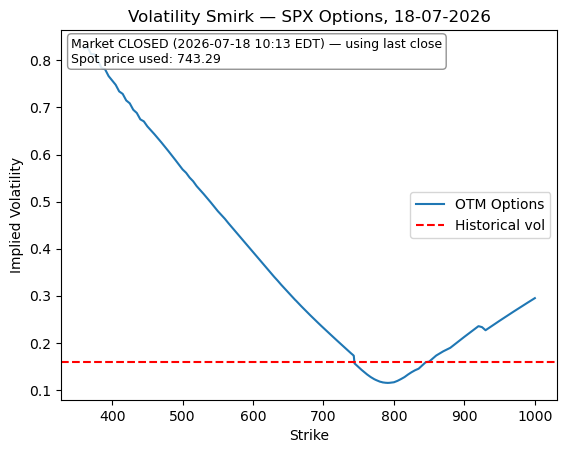

In [7]:

# Combine puts and calls into one continuous line, sorted by strike
combined = pd.concat([liquid_puts, liquid_calls]).sort_values('strike')

status = (
    f"Market {'OPEN' if market_is_open else 'CLOSED'} ({now_et.strftime('%Y-%m-%d %H:%M %Z')}) "
    f"— using {'live data' if market_is_open else 'last close'}\n"
    f"Spot price used: {S:.2f}"
)

plt.text(0.02, 0.98, status,
         transform=plt.gca().transAxes,
         fontsize=9, va='top', ha='left',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.85))


plt.plot(combined['strike'], combined['implied_vol'], color='tab:blue', label='OTM Options')
plt.axhline(hist_vol.iloc[-1].values[0], color='red', linestyle='--', label='Historical vol')

plt.title(f"Volatility Smirk — SPY Options, {datetime.today().strftime('%d-%m-%Y')}")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.legend()
plt.show()
